# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

In [70]:
# Importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)
%matplotlib inline

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Part 1: Data Preparation and Exploration

In [7]:
# Loading Dataset
df=pd.read_csv('C:/Data Science/Assignments_Files/Timeseries/exchange_rate.csv')
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [9]:
# Checking Dataset size
df.shape

(7588, 2)

In [13]:
# Checking Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


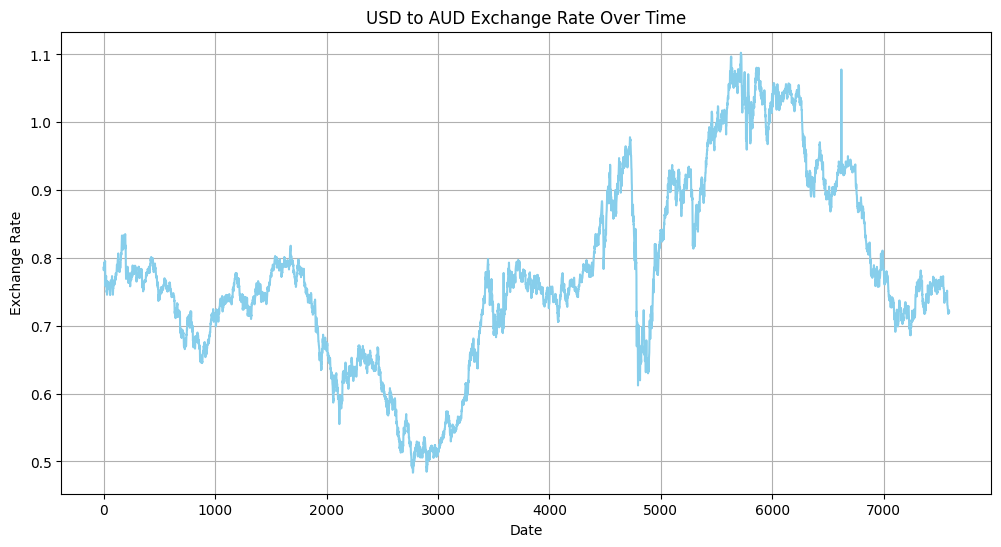

In [21]:
# Initial Exploration (Visualization)
plt.figure(figsize=(12,6))
plt.plot(df['Ex_rate'], color='skyblue')
plt.title("USD to AUD Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid()
plt.show()

In [23]:
# Checking for Duplicates
df.duplicated().sum()

np.int64(0)

In [25]:
# Checking for Null Values
df.isna().sum()

date       0
Ex_rate    0
dtype: int64

### Part 2: Model Building - ARIMA

In [30]:
# Parameter Selection (p, d, q)
result = adfuller(df['Ex_rate'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381528
p-value: 0.4492327353597901


In [32]:
# Findinf Difference
df_diff = df['Ex_rate'].diff().dropna()

In [34]:
# Rerun
result = adfuller(df_diff)
print("p-value after differencing:", result[1])

p-value after differencing: 0.0


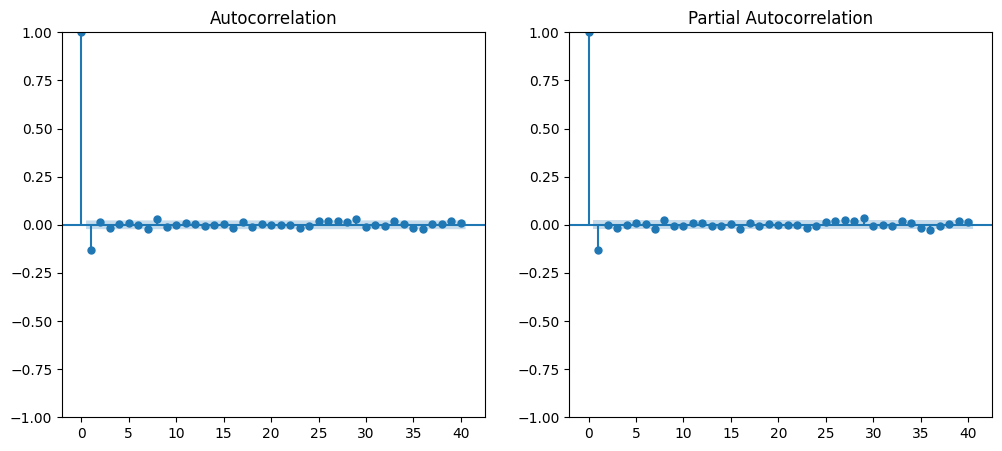

In [38]:
# ACF & PACF Plots (to find p & q)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(df_diff, ax=plt.gca(), lags=40)

plt.subplot(1,2,2)
plot_pacf(df_diff, ax=plt.gca(), lags=40)

plt.show()

In [42]:
# Model Fitting
model = ARIMA(df['Ex_rate'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Mon, 06 Apr 2026   AIC                         -56102.322
Time:                        16:34:49   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

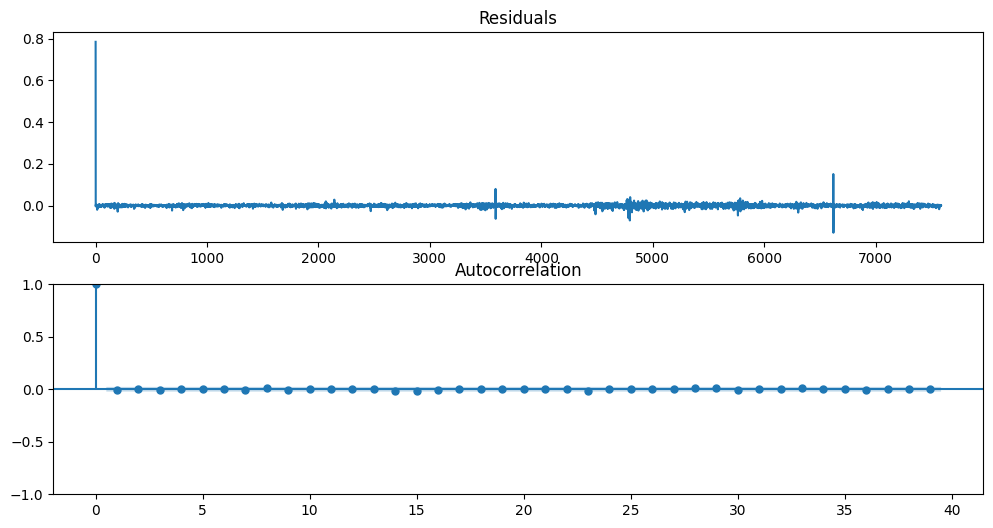

In [44]:
# Diagnostics (Residual Analysis)
residuals = model_fit.resid

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(residuals)
plt.title("Residuals")

plt.subplot(2,1,2)
plot_acf(residuals, ax=plt.gca())

plt.show()

<Axes: title={'center': 'Residual Density'}, ylabel='Density'>

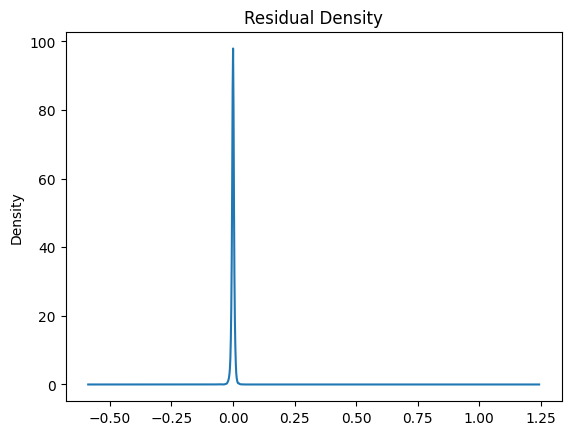

In [46]:
# Normal Distribution Check
residuals.plot(kind='kde', title="Residual Density")

In [48]:
# Forecasting
# Split Data (Train/Test)
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [50]:
# Fit Model on Train
model = ARIMA(train['Ex_rate'], order=(1,1,1))
model_fit = model.fit()

In [52]:
# Forecast
forecast = model_fit.forecast(steps=len(test))

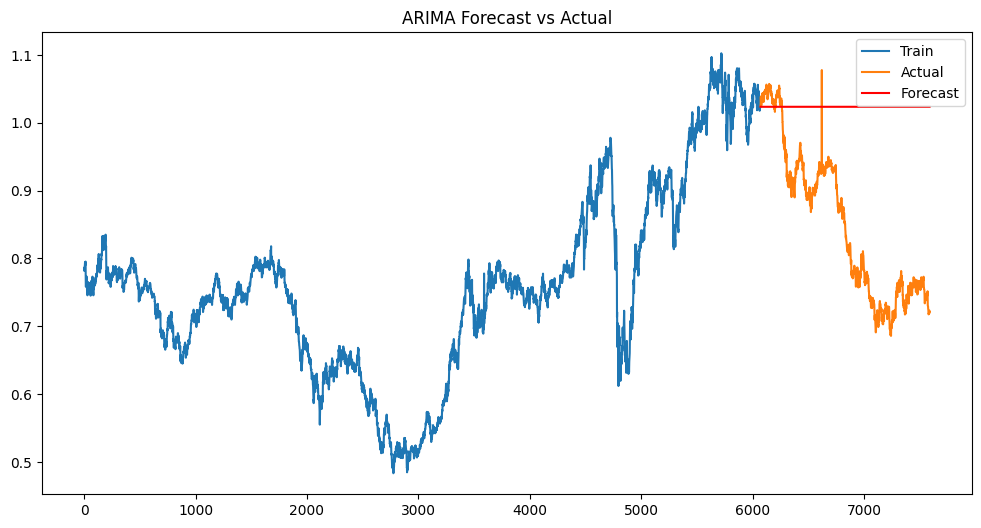

In [54]:
# Visualization
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index, forecast, label='Forecast', color='red')

plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()

### Part 3: Model Building - Exponential Smoothing

In [59]:
# Parameter Optimization
# Using Grind Search approach

best_aic = np.inf
best_model = None

trend_options = ['add', 'mul', None]

for trend in trend_options:
    try:
        model = ExponentialSmoothing(train['Ex_rate'], trend=trend)
        fit = model.fit(optimized=True)
        
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_model = fit
    except:
        continue

print("Best AIC:", best_aic)
print("Best Model:", best_model)

Best AIC: -62659.34327127187
Best Model: <statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper object at 0x000001944CC654F0>


In [61]:
# Model Fitting
fit.summary()

Dep. Variable:,Ex_rate,No. Observations:,6070
Model:,ExponentialSmoothing,SSE,0.199
Optimized:,True,AIC,-62659.343
Trend:,None,BIC,-62645.921
Seasonal:,None,AICC,-62659.337
Seasonal Periods:,None,Date:,"Mon, 06 Apr 2026"
Box-Cox:,False,Time:,16:38:40
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9429396,alpha,True
initial_level,0.7853067,l.0,True


In [63]:
# Forecasting
forecast = fit.forecast(steps=len(test))

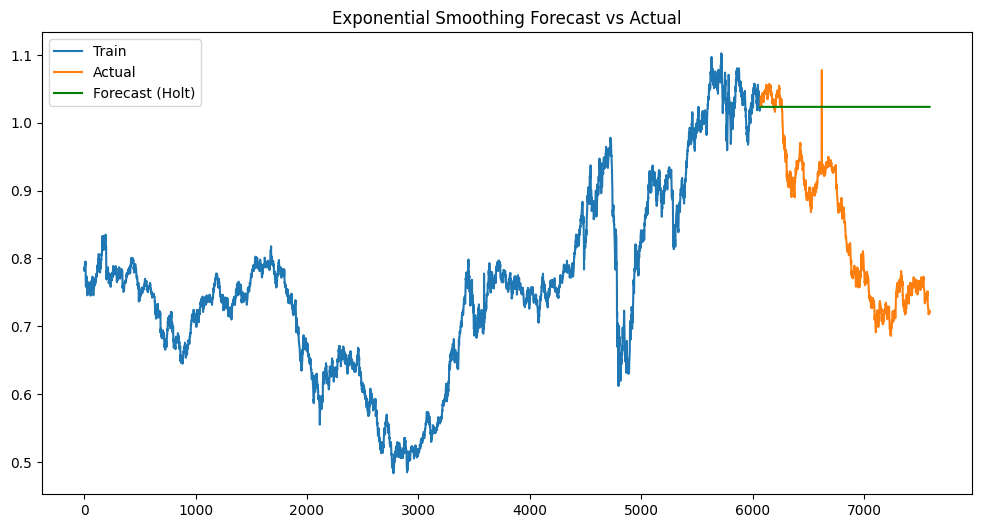

In [67]:
# Visualization

plt.figure(figsize=(12,6))

plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index, forecast, label='Forecast (Holt)', color='green')

plt.title("Exponential Smoothing Forecast vs Actual")
plt.legend()
plt.show()

### Part 4: Evaluation and Comparison

In [74]:
from statsmodels.tsa.arima.model import ARIMA

# Re-fit ARIMA model (IMPORTANT)
arima_model = ARIMA(train['Ex_rate'], order=(1,1,1))
arima_model_fit = arima_model.fit()

# Now forecasting will work
arima_forecast = arima_model_fit.forecast(steps=len(test))

In [76]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(train['Ex_rate'], trend='add')
exp_model_fit = exp_model.fit()

exp_forecast = exp_model_fit.forecast(steps=len(test))

In [78]:
# Compute Error Metrics
# ARIMA Forecast (already computed earlier)
arima_forecast = arima_model_fit.forecast(steps=len(test))

# Exponential Smoothing Forecast
exp_forecast = exp_model_fit.forecast(steps=len(test))

# ARIMA Metrics 
mae_arima = mean_absolute_error(test['Ex_rate'], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test['Ex_rate'], arima_forecast))
mape_arima = np.mean(np.abs((test['Ex_rate'] - arima_forecast) / test['Ex_rate'])) * 100

# Exponential Smoothing Metrics 
mae_exp = mean_absolute_error(test['Ex_rate'], exp_forecast)
rmse_exp = np.sqrt(mean_squared_error(test['Ex_rate'], exp_forecast))
mape_exp = np.mean(np.abs((test['Ex_rate'] - exp_forecast) / test['Ex_rate'])) * 100

# Print Results
print("ARIMA -> MAE:", mae_arima, "RMSE:", rmse_arima, "MAPE:", mape_arima)
print("EXP SMOOTHING -> MAE:", mae_exp, "RMSE:", rmse_exp, "MAPE:", mape_exp)

ARIMA -> MAE: 0.17770970449121345 RMSE: 0.2054366965966928 MAPE: 22.797966173811552
EXP SMOOTHING -> MAE: 0.2065961926538986 RMSE: 0.23910443338090956 MAPE: 26.50866399299623


# Part 4: Evaluation and Comparison

## 1. Error Metrics

ARIMA -> MAE: 0.1777, RMSE: 0.2054, MAPE: 22.80%  
EXPONENTIAL SMOOTHING -> MAE: 0.2066, RMSE: 0.2391, MAPE: 26.51%

---

## 2. Model Comparison

The ARIMA model shows lower values for MAE, RMSE, and MAPE compared to Exponential Smoothing. This indicates that ARIMA provides more accurate predictions.

ARIMA performs better because it captures time-dependent patterns and handles non-stationary data effectively. It is well suited for financial time series like exchange rates.

Exponential Smoothing is simpler and works well for trend-based data, but it cannot capture complex patterns and fluctuations as effectively as ARIMA.

---

## 3. Conclusion

Based on the evaluation metrics, ARIMA performs better than Exponential Smoothing for this dataset. It provides more accurate and reliable forecasts, making it the preferred model for exchange rate prediction.